<a href="https://www.kaggle.com/code/varsha56/netflixanalysis?scriptVersionId=232372547" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/netflix-shows/netflix_titles.csv


In [2]:
df=pd.read_csv("/kaggle/input/netflix-shows/netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 📊 Initial Data Exploration

Let's understand the shape and structure of the dataset:

- Total number of elements
- Column names
- General info and missing values

In [4]:
df.size

105684

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [6]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description     

In [7]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## checking the null values

In [8]:
df[df['director'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,NaN,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada","May 1, 2018",2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...
8796,s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,"January 17, 2017",2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia","September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."


## 🧹 Data Cleaning and Preprocessing

We will clean the dataset by handling missing values and formatting data for analysis:
- Replace missing values in `cast`, `country`, etc. with mode
- Convert `date_added` to datetime
- Extract `year_added` and `month_added` for time-based analysis

In [9]:
df['director']=df['director'].fillna('Unknown')

In [10]:
df.isna().sum()

show_id           0
type              0
title             0
director          0
cast            825
country         831
date_added       10
release_year      0
rating            4
duration          3
listed_in         0
description       0
dtype: int64

## filling the missing data with their modes- taking the very first mode in the case of multipl modes

In [11]:
for a in ['cast','country','date_added','rating','duration']:
    df[a] = df[a].fillna(df[a].mode()[0])

In [12]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nColumn Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isna().sum())
print("\n Description for the dataset:\n",df.describe())

Rows: 8807, Columns: 12

Column Data Types:
 show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

 Description for the dataset:
        release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


In [13]:
df['director'].nunique()

4529

In [14]:
df['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

## Int data type of the release_year column to date

In [15]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y')

In [16]:
df.dtypes

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object

In [17]:
df['date']=df['date_added'].dt.day
df['month']=df['date_added'].dt.month
df['year']=df['date_added'].dt.year

In [18]:
df.dtypes

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
date                     int32
month                    int32
year                     int32
dtype: object

In [19]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date,month,year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,David Attenborough,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021


## Total number of Movies vs TV Shows

In [20]:
type_counts = df['type'].value_counts()
print("Type Distribution:\n", type_counts)

Type Distribution:
 type
Movie      6131
TV Show    2676
Name: count, dtype: int64


## top countries

In [21]:
top_countries = df['country'].value_counts().head(10)
print("Top 10 Countries by Number of Titles:\n", top_countries)

Top 10 Countries by Number of Titles:
 country
United States     3649
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


## Ratings given in the datasets counts

In [22]:
rating_counts = df['rating'].value_counts()
print("Rating Distribution:\n", rating_counts)

Rating Distribution:
 rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


## Year wise contet Addition

In [23]:
df['year_added'] = df['date_added'].dt.year
content_per_year = df['year_added'].value_counts().sort_index()
print("Content Added per Year:\n", content_per_year)

Content Added per Year:
 year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1889
2021    1498
Name: count, dtype: int64


## top ten directors

In [24]:
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)
print("Top 10 Directors:\n", top_directors)

Top 10 Directors:
 director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


## Top Actors employed in the show

In [25]:
all_cast = df[df['cast'] != 'Unknown']['cast'].str.split(', ').explode()
top_cast = all_cast.value_counts().head(10)
print("Top 10 Cast Members:\n", top_cast)

Top 10 Cast Members:
 cast
David Attenborough    845
Anupam Kher            43
Shah Rukh Khan         35
Julie Tejwani          33
Naseeruddin Shah       32
Takahiro Sakurai       32
Rupa Bhimani           31
Om Puri                30
Akshay Kumar           30
Yuki Kaji              29
Name: count, dtype: int64


## Average durations for the movies

In [26]:
df_movies = df[df['type'] == 'Movie']
df_movies['duration_mins'] = df_movies['duration'].str.extract('(\d+)').astype(float)
average_duration = df_movies['duration_mins'].mean()
print(f"Average Movie Duration: {average_duration:.2f} minutes")

Average Movie Duration: 99.53 minutes


<ipython-input-26-316fb0789878>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies['duration_mins'] = df_movies['duration'].str.extract('(\d+)').astype(float)


## TV Shows by Number of Seasons

In [27]:
df_shows = df[df['type'] == 'TV Show']
df_shows['seasons'] = df_shows['duration'].str.extract('(\d+)').astype(int)
season_counts = df_shows['seasons'].value_counts().sort_index()
print("TV Shows by Number of Seasons:\n", season_counts)

TV Shows by Number of Seasons:
 seasons
1     1793
2      425
3      199
4       95
5       65
6       33
7       23
8       17
9        9
10       7
11       2
12       2
13       3
15       2
17       1
Name: count, dtype: int64


<ipython-input-27-cb56707d1d76>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_shows['seasons'] = df_shows['duration'].str.extract('(\d+)').astype(int)


## Number of unique values in the datset

In [28]:
unique_summary = df.nunique().sort_values(ascending=False)
print("Unique Values per Column:\n", unique_summary)

Unique Values per Column:
 show_id         8807
title           8807
description     8775
cast            7692
director        4529
date_added      1714
country          748
listed_in        514
duration         220
release_year      74
date              31
rating            17
year              14
year_added        14
month             12
type               2
dtype: int64


## TOp languages by frequency

In [29]:
exp = df['country'].str.split(', ').explode()
exp

0       United States
1        South Africa
2       United States
3       United States
4               India
            ...      
8802    United States
8803    United States
8804    United States
8805    United States
8806            India
Name: country, Length: 10845, dtype: object

In [30]:
language_proxy = df['country'].str.split(', ').explode().value_counts().head(10)
print("Top 10 Content-Producing Countries:\n", language_proxy)

Top 10 Content-Producing Countries:
 country
United States     4520
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


## Avergae duration grouped by ratings

In [31]:
df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration_mins'] = pd.to_numeric(df_movies['duration'].str.extract('(\d+)')[0])

avg_dur_rating = df_movies.groupby('rating')['duration_mins'].mean().sort_values(ascending=False)
print("Average Duration by Rating:\n", avg_dur_rating)

Average Duration by Rating:
 rating
NC-17       125.000000
TV-14       110.290820
PG-13       108.330612
R           106.720201
UR          106.333333
PG           98.282230
TV-MA        95.870640
TV-PG        94.851852
NR           94.533333
G            90.268293
TV-G         79.666667
TV-Y7-FV     68.400000
TV-Y7        66.287770
TV-Y         48.114504
74 min        1.000000
84 min        1.000000
66 min        1.000000
Name: duration_mins, dtype: float64


## TV shows season distribution summary

In [32]:
df_shows = df[df['type'] == 'TV Show'].copy()
df_shows['seasons'] = pd.to_numeric(df_shows['duration'].str.extract('(\d+)')[0])
seasons_summary = df_shows['seasons'].describe()
print("TV Show Seasons Summary:\n", seasons_summary)

TV Show Seasons Summary:
 count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: seasons, dtype: float64


## Content added overtime

In [33]:
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

yearly_additions = df.groupby('year_added').size()
monthly_avg = df.groupby('month_added').size().div(df['year_added'].nunique()).round(2)

print("Titles Added Per Year:\n", yearly_additions)
print("\nAverage Monthly Additions Across All Years:\n", monthly_avg)

Titles Added Per Year:
 year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1889
2021    1498
dtype: int64

Average Monthly Additions Across All Years:
 month_added
1     53.43
2     40.21
3     53.00
4     54.57
5     45.14
6     52.00
7     59.07
8     53.93
9     55.00
10    54.29
11    50.36
12    58.07
dtype: float64


## The ratio of movies to shows for Each year

In [34]:
type_ratio_per_year = df.pivot_table(index='year_added', columns='type', values='title', aggfunc='count').fillna(0)
type_ratio_per_year['Movie_to_TV_Ratio'] = (type_ratio_per_year['Movie'] / type_ratio_per_year['TV Show']).round(2)
print("Movies vs TV Shows Ratio Per Year:\n", type_ratio_per_year[['Movie', 'TV Show', 'Movie_to_TV_Ratio']])

Movies vs TV Shows Ratio Per Year:
 type         Movie  TV Show  Movie_to_TV_Ratio
year_added                                    
2008           1.0      1.0               1.00
2009           2.0      0.0                inf
2010           1.0      0.0                inf
2011          13.0      0.0                inf
2012           3.0      0.0                inf
2013           6.0      5.0               1.20
2014          19.0      5.0               3.80
2015          56.0     26.0               2.15
2016         253.0    176.0               1.44
2017         839.0    349.0               2.40
2018        1237.0    412.0               3.00
2019        1424.0    592.0               2.41
2020        1284.0    605.0               2.12
2021         993.0    505.0               1.97


## The most frquenct genre

In [35]:
genre_combos = df['listed_in'].apply(lambda x: ', '.join(sorted(x))).value_counts().head(10)
print("Most Frequent Genre Combinations:\n", genre_combos)

Most Frequent Genre Combinations:
 listed_in
 ,  , ,, D, I, M, a, a, a, a, e, e, i, i, l, m, n, n, n, o, o, r, r, s, s, t, t, v                                                                362
D, a, c, e, e, i, m, n, o, r, s, t, u                                                                                                             359
 , -, C, S, U, a, d, d, e, m, n, o, p, t, y                                                                                                       334
 ,  ,  , ,, ,, C, D, I, M, a, a, a, a, d, e, e, e, e, i, i, i, l, m, m, n, n, n, o, o, o, r, r, s, s, s, t, t, v                                  274
 ,  ,  ,  , ,, ,, D, I, I, M, M, a, a, a, a, d, d, e, e, e, e, e, e, i, i, i, l, m, n, n, n, n, n, n, o, o, o, p, r, r, s, s, s, t, t, t, v, v    252
 , ', K, T, V, d, i, s                                                                                                                            220
 ,  ,  , &, C, F, M, a, d, e, e, h, i, i, i, l, l, m, n

## Earliest and the latest content creted

In [36]:
earliest = df.loc[df['date_added'].idxmin()][['title', 'date_added']]
latest = df.loc[df['date_added'].idxmax()][['title', 'date_added']]
print(f"Earliest Title Added: {earliest['title']} on {earliest['date_added'].date()}")
print(f"Latest Title Added: {latest['title']} on {latest['date_added'].date()}")

Earliest Title Added: To and From New York on 2008-01-01
Latest Title Added: Dick Johnson Is Dead on 2021-09-25


In [37]:
import matplotlib.pyplot as plt
plt.style.use('seaborn')

<ipython-input-37-036bcfb1f050>:2: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


## 📈 Exploratory Data Analysis (EDA)

Let's analyze key aspects of the data like:
- Content type distribution
- Year-wise additions
- Top genres, actors, and countries

## Bar Chart for the Movies vs TV show count

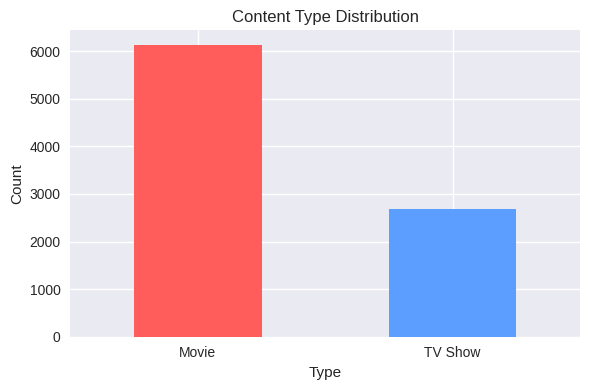

In [38]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(6, 4))
type_counts.plot(kind='bar', color=['#FF5C5C', '#5C9EFF'])
plt.title('Content Type Distribution')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Line chart of the title per year

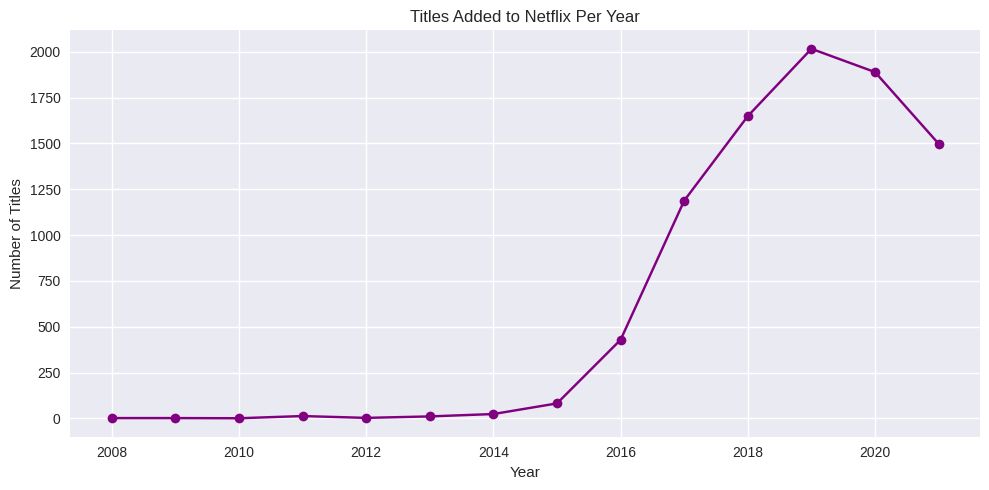

In [39]:
titles_per_year = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(titles_per_year.index, titles_per_year.values, marker='o', color='purple')
plt.title('Titles Added to Netflix Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.tight_layout()
plt.show()

## top ten countries by content frequencies

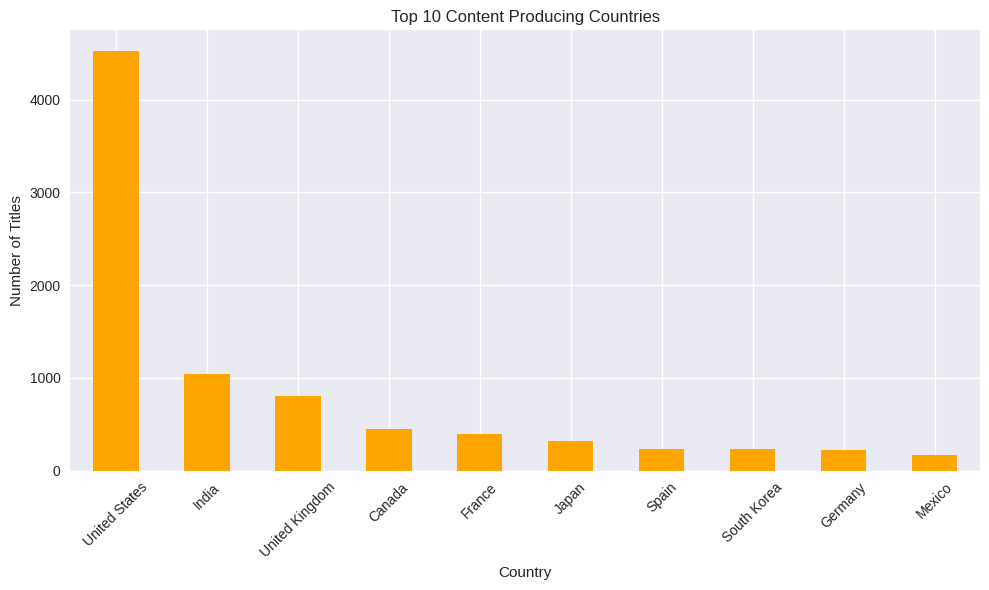

In [40]:
top_countries = df['country'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10, 6))
top_countries.plot(kind='bar', color='orange')
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## The content ratings distributions (limiting to top 6)

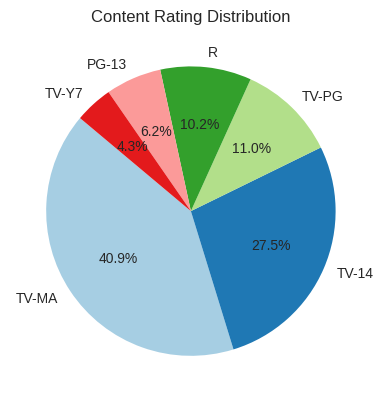

In [41]:
rating_dist = df['rating'].value_counts().head(6)  

plt.figure(figsize=(4,5))
plt.pie(rating_dist, labels=rating_dist.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Content Rating Distribution')
plt.tight_layout()
plt.show()

## Histogram for the movies duration

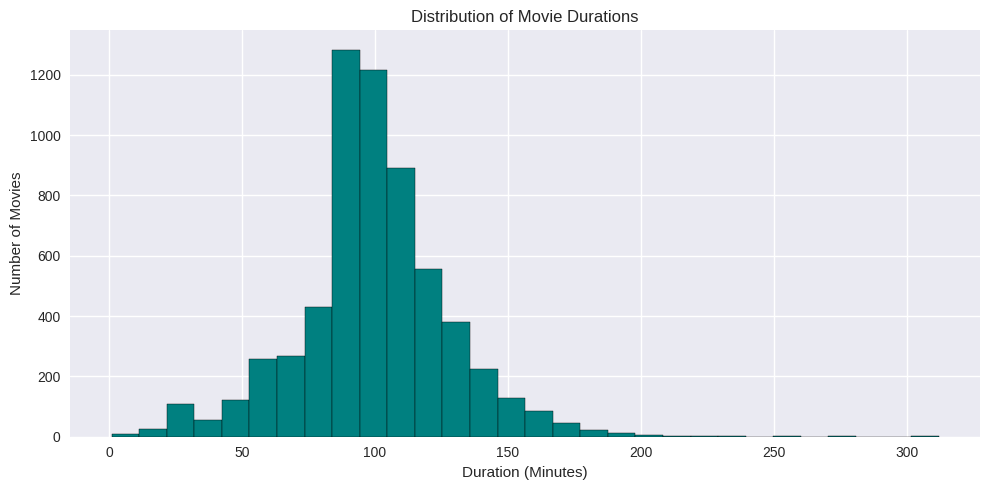

In [42]:
df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration_mins'] = pd.to_numeric(df_movies['duration'].str.extract('(\d+)')[0])

plt.figure(figsize=(10, 5))
plt.hist(df_movies['duration_mins'].dropna(), bins=30, color='teal', edgecolor='black')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.show()


## BAr chart for the top 10 most frequent genres

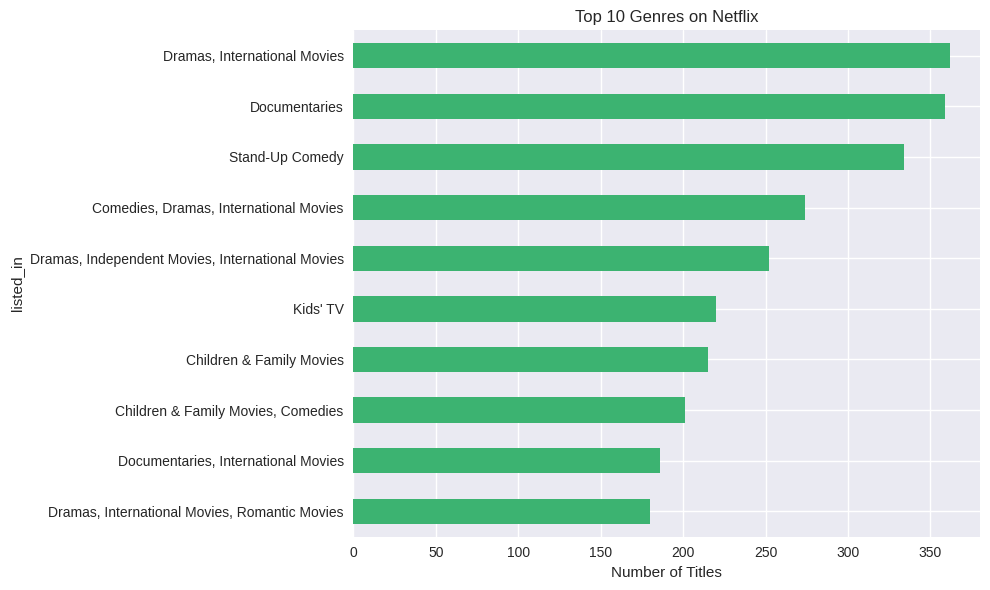

In [43]:
genre_series = df['listed_in'].explode().str.strip()
top_genres = genre_series.value_counts().head(10)

plt.figure(figsize=(10, 6))
top_genres.plot(kind='barh', color='mediumseagreen')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## TV shows by number of seasons

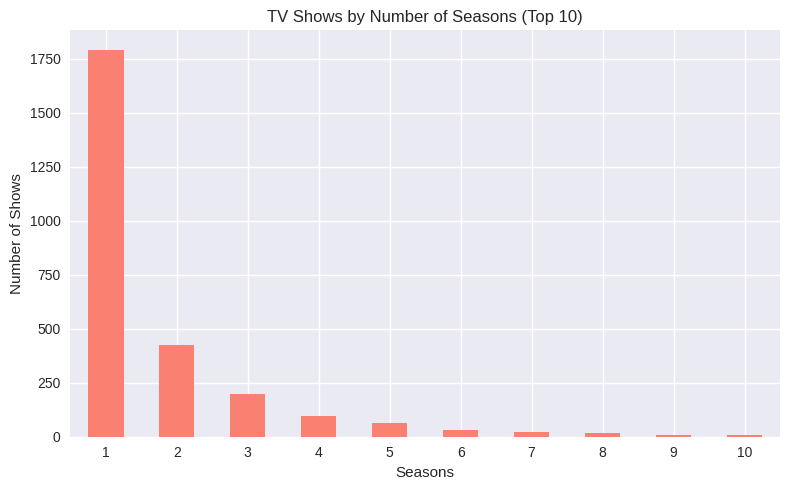

In [44]:
df_shows = df[df['type'] == 'TV Show'].copy()
df_shows['seasons'] = pd.to_numeric(df_shows['duration'].str.extract('(\d+)')[0])
season_counts = df_shows['seasons'].value_counts().sort_index().head(10)

plt.figure(figsize=(8, 5))
season_counts.plot(kind='bar', color='salmon')
plt.title('TV Shows by Number of Seasons (Top 10)')
plt.xlabel('Seasons')
plt.ylabel('Number of Shows')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Movies versus TV shows trend

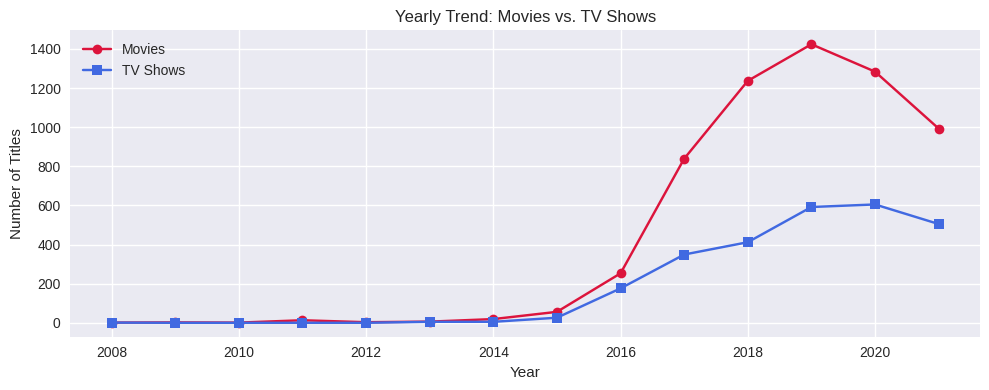

In [45]:
content_trend = df.pivot_table(index='year_added', columns='type', values='title', aggfunc='count').fillna(0)

plt.figure(figsize=(10, 4))
plt.plot(content_trend.index, content_trend['Movie'], marker='o', label='Movies', color='crimson')
plt.plot(content_trend.index, content_trend['TV Show'], marker='s', label='TV Shows', color='royalblue')
plt.title('Yearly Trend: Movies vs. TV Shows')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## STacked Bar chart for the movies versus TV shows per year

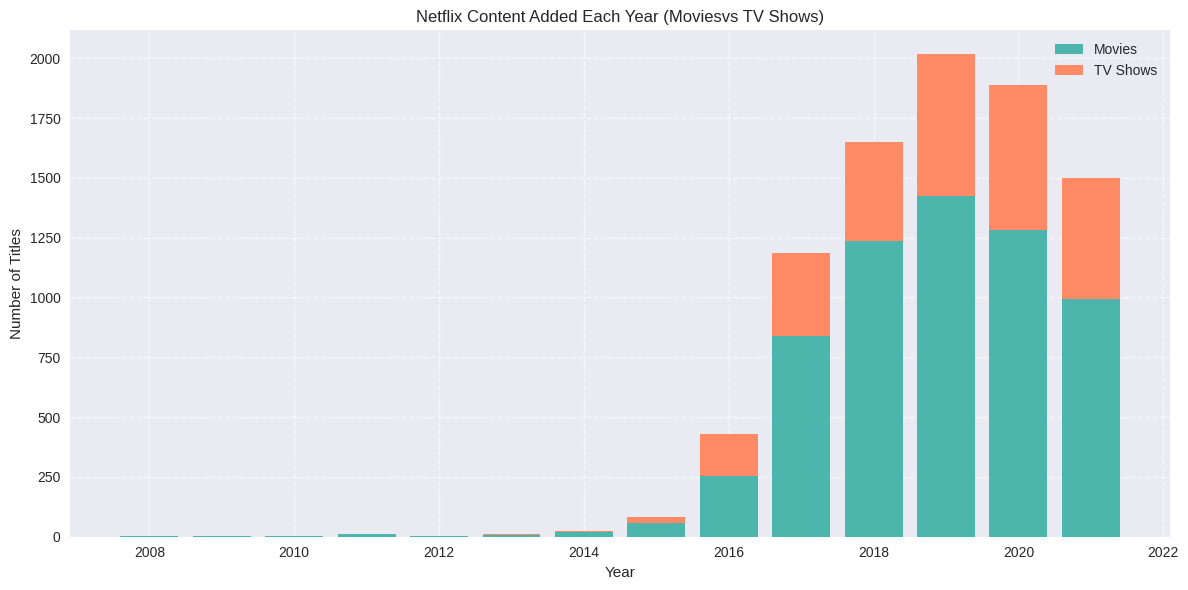

In [46]:
df['year_added'] = df['date_added'].dt.year
type_by_year = df.pivot_table(index='year_added', columns='type', values='title', aggfunc='count').fillna(0)

plt.figure(figsize=(12, 6))
plt.bar(type_by_year.index, type_by_year['Movie'], label='Movies', color='#4DB6AC')
plt.bar(type_by_year.index, type_by_year['TV Show'], bottom=type_by_year['Movie'], label='TV Shows', color='#FF8A65')
plt.title('Netflix Content Added Each Year (Moviesvs TV Shows)')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## The ratings distributions byy type

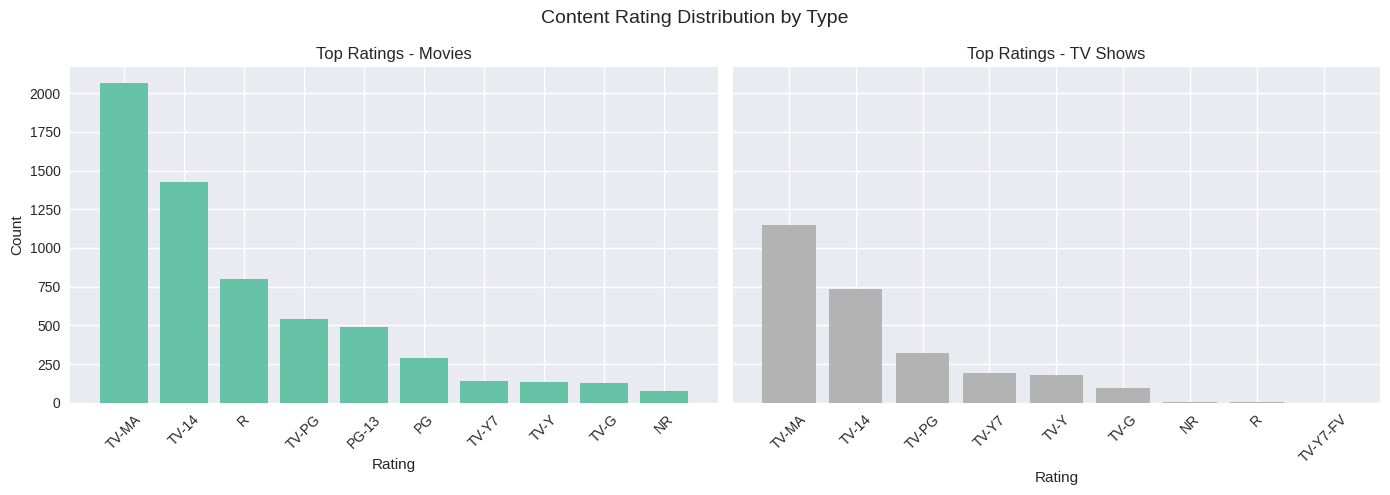

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, t in enumerate(['Movie', 'TV Show']):
    df_type = df[df['type'] == t]
    rating_counts = df_type['rating'].value_counts().head(10)
    axs[i].bar(rating_counts.index, rating_counts.values, color=plt.cm.Set2(i * 25))
    axs[i].set_title(f'Top Ratings - {t}s')
    axs[i].set_xlabel('Rating')
    axs[i].tick_params(axis='x', rotation=45)

axs[0].set_ylabel('Count')
fig.suptitle('Content Rating Distribution by Type', fontsize=14)
plt.tight_layout()
plt.show()

## Top ten directors

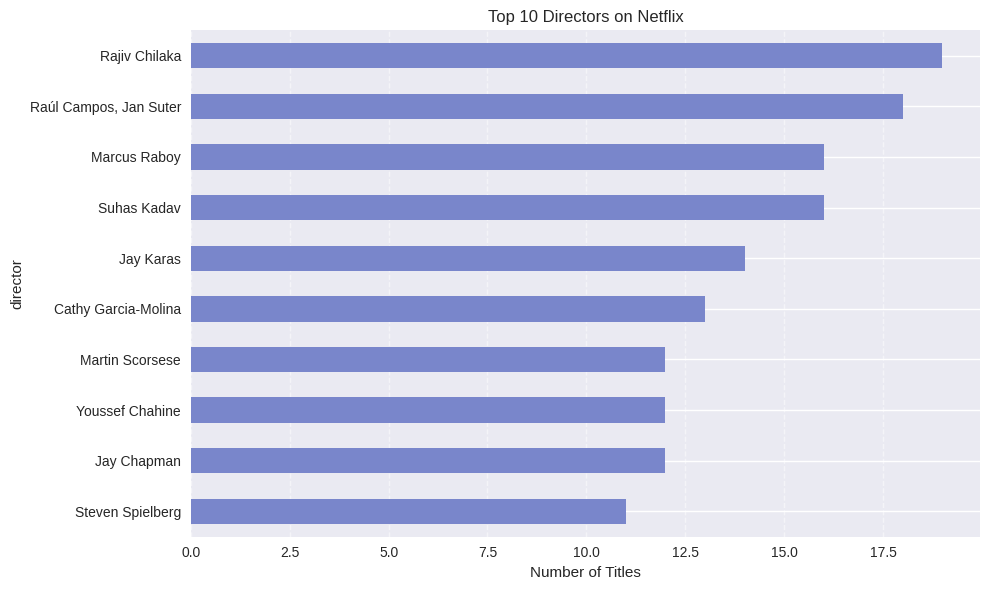

In [48]:
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_directors.plot(kind='barh', color='#7986CB')
plt.title('Top 10 Directors on Netflix')
plt.xlabel('Number of Titles')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## movie length categories

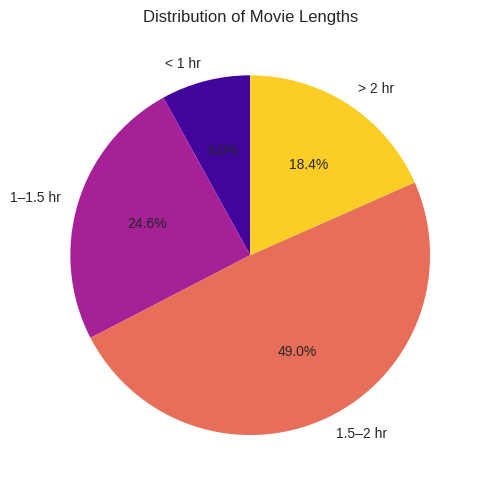

In [49]:
df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration_mins'] = pd.to_numeric(df_movies['duration'].str.extract('(\d+)')[0])
bins = [0, 60, 90, 120, 200]
labels = ['< 1 hr', '1–1.5 hr', '1.5–2 hr', '> 2 hr']
df_movies['length_category'] = pd.cut(df_movies['duration_mins'], bins=bins, labels=labels)

length_dist = df_movies['length_category'].value_counts().sort_index()

plt.figure(figsize=(5,5))
plt.pie(length_dist, labels=length_dist.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.plasma(np.linspace(0.1, 0.9, len(length_dist))))
plt.title('Distribution of Movie Lengths')
plt.tight_layout()
plt.show()

## Genre occurrence- Hetmap styled Barplots

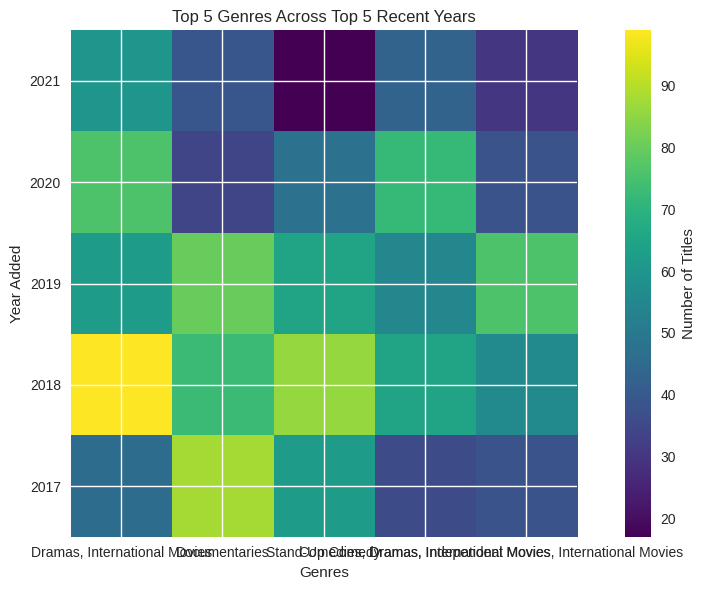

In [50]:
top_years = df['year_added'].value_counts().sort_index(ascending=False).head(5).index
top_genres = df['listed_in'].explode().str.strip().value_counts().head(5).index

genre_matrix = pd.DataFrame(0, index=top_years, columns=top_genres)

for year in top_years:
    yearly_data = df[df['year_added'] == year]
    exploded = yearly_data['listed_in'].explode().str.strip()
    counts = exploded[exploded.isin(top_genres)].value_counts()
    genre_matrix.loc[year, counts.index] = counts.values

plt.figure(figsize=(10, 6))
plt.imshow(genre_matrix, cmap='viridis')
plt.colorbar(label='Number of Titles')
plt.xticks(ticks=range(len(top_genres)), labels=top_genres)
plt.yticks(ticks=range(len(top_years)), labels=top_years)
plt.title('Top 5 Genres Across Top 5 Recent Years')
plt.xlabel('Genres')
plt.ylabel('Year Added')
plt.tight_layout()
plt.show()

## Release yea versus the Add Year 

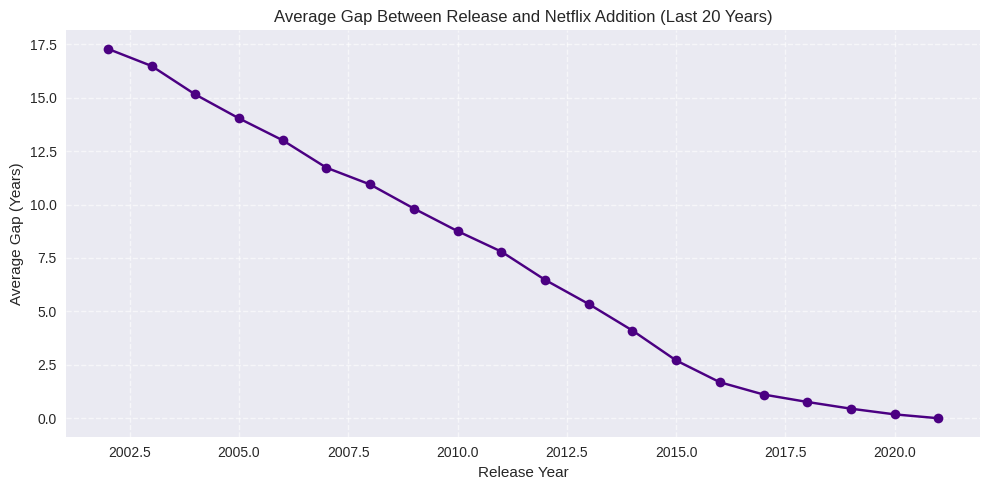

In [51]:
df['release_year'] = df['release_year'].astype(int)
df['gap'] = df['year_added'] - df['release_year']
gap_by_year = df.groupby('release_year')['gap'].mean().dropna().tail(20)

plt.figure(figsize=(10, 5))
plt.plot(gap_by_year.index, gap_by_year.values, marker='o', color='indigo')
plt.title('Average Gap Between Release and Netflix Addition (Last 20 Years)')
plt.xlabel('Release Year')
plt.ylabel('Average Gap (Years)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<ipython-input-52-0e7e4cbf8b90>:10: UserWarning: Glyph 127849 (\N{DOUGHNUT}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127849 (\N{DOUGHNUT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


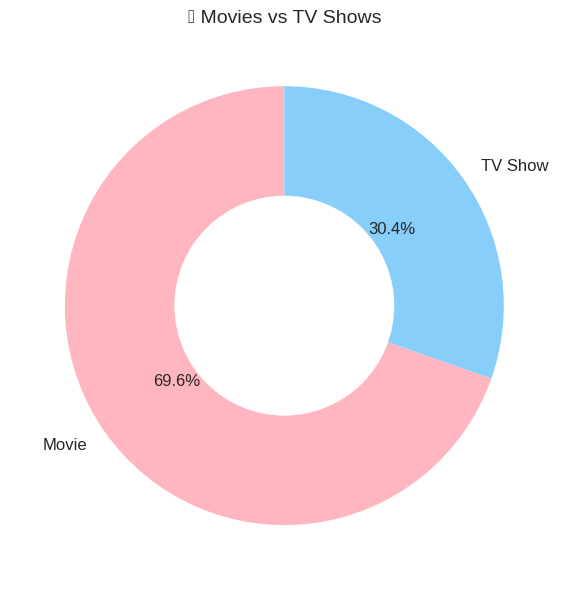

In [52]:
type_counts = df['type'].value_counts()
colors = ['#FFB6C1', '#87CEFA']

plt.figure(figsize=(6, 6))
wedges, texts, autotexts = plt.pie(type_counts, labels=type_counts.index,
                                   autopct='%1.1f%%', startangle=90, colors=colors, textprops={'fontsize': 12})

plt.gca().add_artist(plt.Circle((0, 0), 0.5, color='white'))
plt.title("🍩 Movies vs TV Shows", fontsize=14)
plt.tight_layout()
plt.show()

<ipython-input-53-bac448e7ce42>:10: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


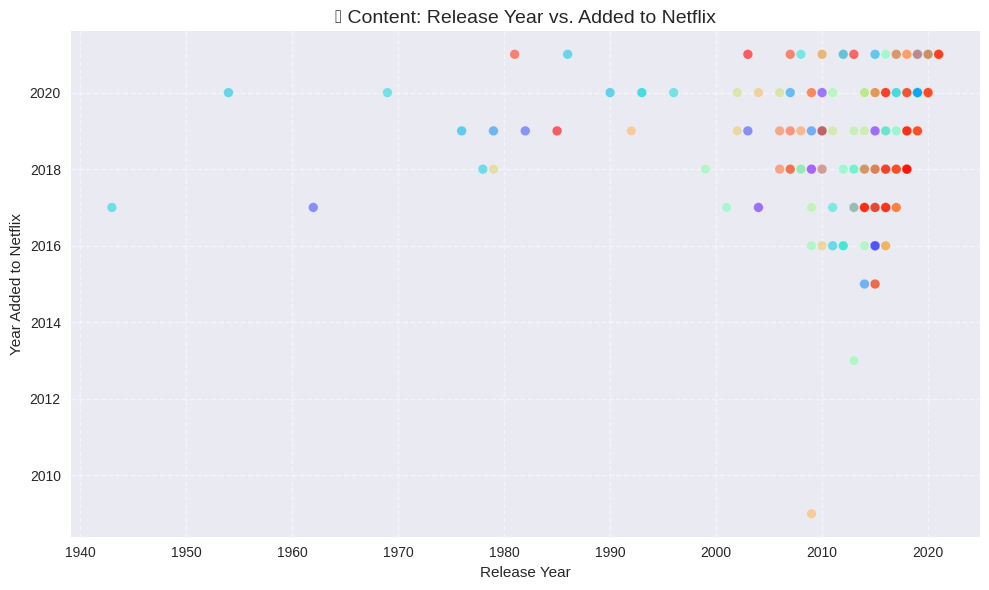

In [53]:
sample_df = df[['release_year', 'year_added']].dropna().sample(300, random_state=42)
colors = plt.cm.rainbow(np.linspace(0, 1, len(sample_df)))

plt.figure(figsize=(10, 6))
plt.scatter(sample_df['release_year'], sample_df['year_added'], color=colors, alpha=0.6, edgecolor='white')
plt.title('🌟 Content: Release Year vs. Added to Netflix', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Year Added to Netflix')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<ipython-input-54-a60544aa0ea9>:15: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128198 (\N{TEAR-OFF CALENDAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


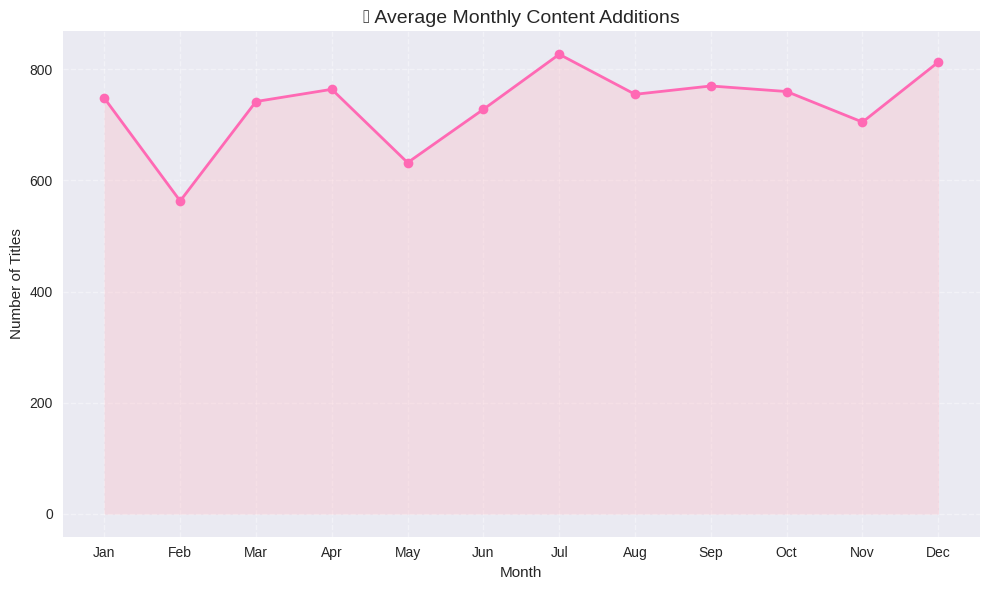

In [54]:
df['month_added'] = df['date_added'].dt.month
monthly_avg = df.groupby('month_added')['show_id'].count()

plt.figure(figsize=(10, 6))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linestyle='-', color='#FF69B4', linewidth=2)
plt.fill_between(monthly_avg.index, monthly_avg.values, color='#FFB6C1', alpha=0.3)

plt.xticks(np.arange(1, 13), 
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('📆 Average Monthly Content Additions', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

<ipython-input-55-c5eef194f24c>:14: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


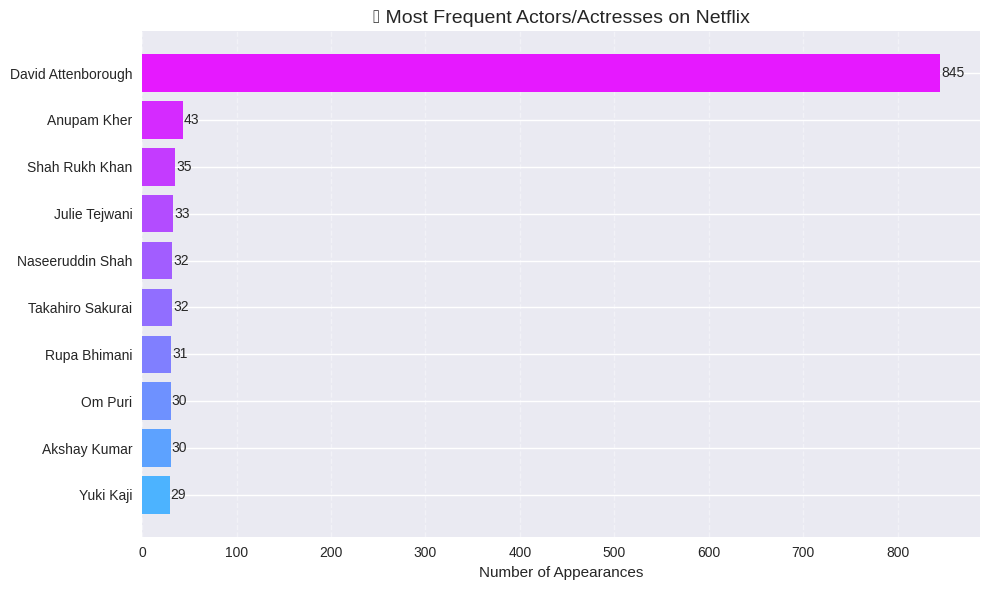

In [55]:
top_casts = df['cast'].dropna().str.split(', ').explode().value_counts().head(10)
colors = plt.cm.cool(np.linspace(0.3, 0.9, 10))

plt.figure(figsize=(10, 6))
bars = plt.barh(top_casts.index[::-1], top_casts.values[::-1], color=colors)
plt.title('🌟 Most Frequent Actors/Actresses on Netflix', fontsize=14)
plt.xlabel('Number of Appearances')
plt.grid(axis='x', linestyle='--', alpha=0.4)


for i, v in enumerate(top_casts.values[::-1]):
    plt.text(v + 1, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

<ipython-input-56-1280da6fbce0>:19: UserWarning: Glyph 127880 (\N{BALLOON}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127880 (\N{BALLOON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


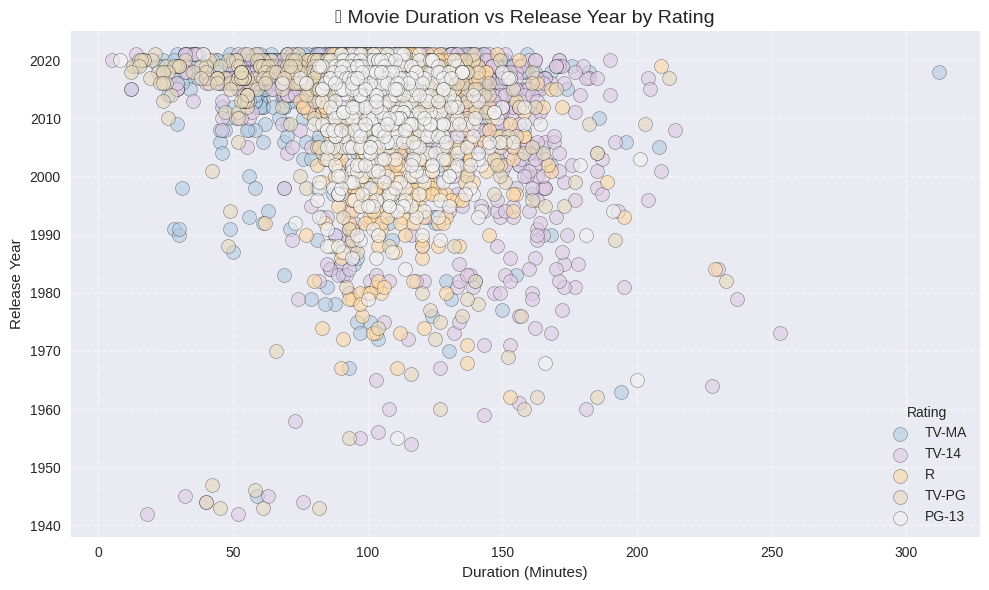

In [56]:
movie_df = df[df['type'] == 'Movie'].copy()
movie_df['duration_mins'] = pd.to_numeric(movie_df['duration'].str.extract('(\d+)')[0])
rating_count = movie_df['rating'].value_counts().head(5).index
movie_filtered = movie_df[movie_df['rating'].isin(rating_count)]

colors = plt.cm.Pastel1(np.linspace(0.2, 0.9, len(rating_count)))

plt.figure(figsize=(10, 6))
for i, rate in enumerate(rating_count):
    sub = movie_filtered[movie_filtered['rating'] == rate]
    plt.scatter(sub['duration_mins'], sub['release_year'], 
                s=100, alpha=0.6, color=colors[i], label=rate, edgecolor='black')

plt.title('🎈 Movie Duration vs Release Year by Rating', fontsize=14)
plt.xlabel('Duration (Minutes)')
plt.ylabel('Release Year')
plt.legend(title='Rating')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 🧠 Key Insights and Summary

- Most Netflix content is **Movies**, not TV Shows.
- The peak year for adding content was around 2019–2020.
- Popular genres include **Dramas**, **International Movies**, and **Comedies**.
- The **United States** dominates content production, followed by **India**.
- Most content is targeted towards **TV-MA** and **TV-14** age groups.

> Further analysis could explore audience ratings, language diversity, and genre trends over time.